<a href="https://colab.research.google.com/github/Hemanthkanakanti/Trader-Performance-vs-Market-Sentiment/blob/main/Data%20preparation%20and%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import gdown

# --- Dataset 1: Bitcoin Market Sentiment (Fear/Greed) ---
drive_link_sentiment = 'https://drive.google.com/file/d/1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf/view?usp=sharing'
output_sentiment_file = 'bitcoin_sentiment.csv'

# --- Dataset 2: Historical Trader Data (Hyperliquid) ---
drive_link_trader = 'https://drive.google.com/file/d/1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs/view?usp=sharing'
output_trader_file = 'hyperliquid_trader_data.csv'

print(f"Downloading {output_sentiment_file}...")
gdown.download(drive_link_sentiment, output_sentiment_file, fuzzy=True, quiet=True)
print(f"Downloading {output_trader_file}...")
gdown.download(drive_link_trader, output_trader_file, fuzzy=True, quiet=True)

# Load datasets
sentiment_df = pd.read_csv(output_sentiment_file)
trader_df = pd.read_csv(output_trader_file)

print("\n--- Bitcoin Market Sentiment Data (sentiment_df) ---")
print(f"Number of rows: {sentiment_df.shape[0]}, Number of columns: {sentiment_df.shape[1]}")
print("\nMissing values per column:")
print(sentiment_df.isnull().sum())
print(f"\nNumber of duplicate rows: {sentiment_df.duplicated().sum()}")

print("\n--- Hyperliquid Trader Data (trader_df) ---")
print(f"Number of rows: {trader_df.shape[0]}, Number of columns: {trader_df.shape[1]}")
print("\nMissing values per column:")
print(trader_df.isnull().sum())
print(f"\nNumber of duplicate rows: {trader_df.duplicated().sum()}")


--- Bitcoin Market Sentiment Data (sentiment_df) ---
Number of rows: 2644, Number of columns: 4

Missing values per column:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Number of duplicate rows: 0

--- Hyperliquid Trader Data (trader_df) ---
Number of rows: 211224, Number of columns: 16

Missing values per column:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Number of duplicate rows: 0


In [ ]:
# Convert sentiment_df 'timestamp' to datetime and extract date
sentiment_df['date_dt'] = pd.to_datetime(sentiment_df['timestamp'], unit='s').dt.date
# Convert sentiment_df 'date' column (which is already a date string) to datetime.date object
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

# Ensure the 'date' columns are consistent. We'll prioritize the 'date_dt' derived from 'timestamp'
sentiment_df['aligned_date'] = sentiment_df['date_dt']

# Convert trader_df 'Timestamp' to datetime and extract date
trader_df['aligned_date'] = pd.to_datetime(trader_df['Timestamp'], unit='ms').dt.date # Assuming 'Timestamp' is in milliseconds

print("\n--- Info for sentiment_df after date conversion ---")
sentiment_df.info()

print("\n--- Info for trader_df after date conversion ---")
trader_df.info()

print("\n--- First 5 rows of sentiment_df with new date column ---")
display(sentiment_df[['timestamp', 'date', 'date_dt', 'aligned_date']].head())

print("\n--- First 5 rows of trader_df with new date column ---")
display(trader_df[['Timestamp', 'aligned_date']].head())


--- Info for sentiment_df after date conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
 4   date_dt         2644 non-null   object
 5   aligned_date    2644 non-null   object
dtypes: int64(2), object(4)
memory usage: 124.1+ KB

--- Info for trader_df after date conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-nu

,timestamp,date,date_dt,aligned_date
0,1517463000,2018-02-01,2018-02-01,2018-02-01
1,1517549400,2018-02-02,2018-02-02,2018-02-02
2,1517635800,2018-02-03,2018-02-03,2018-02-03
3,1517722200,2018-02-04,2018-02-04,2018-02-04
4,1517808600,2018-02-05,2018-02-05,2018-02-05



--- First 5 rows of trader_df with new date column ---


,Timestamp,aligned_date
0,1.730000e+12,2024-10-27
1,1.730000e+12,2024-10-27
2,1.730000e+12,2024-10-27
3,1.730000e+12,2024-10-27
4,1.730000e+12,2024-10-27


In [ ]:
# Merge the two dataframes on the 'aligned_date' column
# We'll perform a left merge, keeping all rows from trader_df and adding sentiment data where dates match.
merged_df = pd.merge(trader_df, sentiment_df[['aligned_date', 'value', 'classification']],
                     on='aligned_date', how='left')

print("\n--- First 5 rows of the merged DataFrame ---")
display(merged_df.head())

print("\n--- Info for the merged DataFrame ---")
merged_df.info()

print("\n--- Missing values in the merged DataFrame (after merge) ---")
print(merged_df.isnull().sum())


--- First 5 rows of the merged DataFrame ---


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,aligned_date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,74.0,Greed



--- Info for the merged DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-

### Calculating Key Metrics

In [ ]:
# 1. Daily PnL per trader (or per account)
daily_pnl_per_account = merged_df.groupby(['Account', 'aligned_date'])['Closed PnL'].sum().reset_index()
daily_pnl_per_account.rename(columns={'Closed PnL': 'Daily PnL'}, inplace=True)

print("\n--- Daily PnL per Account (first 5 rows) ---")
display(daily_pnl_per_account.head())


--- Daily PnL per Account (first 5 rows) ---


,Account,aligned_date,Daily PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [ ]:
# 2. Win Rate per account
# A win is defined as Closed PnL > 0
account_performance = merged_df.groupby('Account').agg(
    total_trades=('Trade ID', 'count'),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()

account_performance['win_rate'] = (account_performance['winning_trades'] / account_performance['total_trades']) * 100

print("\n--- Account Performance (Win Rate, first 5 rows) ---")
display(account_performance.head())


--- Account Performance (Win Rate, first 5 rows) ---


,Account,total_trades,winning_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1373,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,3223,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,1150,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,5838,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1684,51.991355


In [ ]:
# 3. Average Trade Size (in USD) per account
avg_trade_size_per_account = merged_df.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size_per_account.rename(columns={'Size USD': 'Average Trade Size (USD)'}, inplace=True)

print("\n--- Average Trade Size per Account (first 5 rows) ---")
display(avg_trade_size_per_account.head())


--- Average Trade Size per Account (first 5 rows) ---


,Account,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [ ]:
# 4. Number of trades per day
trades_per_day = merged_df.groupby('aligned_date')['Trade ID'].count().reset_index()
trades_per_day.rename(columns={'Trade ID': 'Number of Trades'}, inplace=True)

print("\n--- Number of Trades per Day (first 5 rows) ---")
display(trades_per_day.head())


--- Number of Trades per Day (first 5 rows) ---


,aligned_date,Number of Trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [ ]:
# 5. Long/Short Ratio per day
# Assuming 'BUY' corresponds to a long position and 'SELL' to a short position
long_short_counts = merged_df.groupby(['aligned_date', 'Side']).size().unstack(fill_value=0).reset_index()

# Calculate long/short ratio
# To avoid division by zero, handle cases where 'SELL' count might be 0
long_short_counts['long_short_ratio'] = long_short_counts.apply(
    lambda row: row['BUY'] / row['SELL'] if row['SELL'] != 0 else (row['BUY'] / 1e-6 if row['BUY'] !=0 else 0),
    axis=1
)

print("\n--- Daily Long/Short Ratio (first 5 rows) ---")
display(long_short_counts.head())


--- Daily Long/Short Ratio (first 5 rows) ---


Side,aligned_date,BUY,SELL,long_short_ratio
0,2023-03-28,3,0,3.000000e+06
1,2023-11-14,491,554,8.862816e-01
2,2024-03-09,3371,3591,9.387357e-01
3,2024-07-03,3505,3636,9.639714e-01
4,2024-10-27,14927,20314,7.348134e-01


### Part B: Performance Analysis based on Market Sentiment

To analyze performance differences between 'Fear' and 'Greed' days, we'll first define broad sentiment categories based on the existing `classification` column. We will then calculate average PnL, win rate, and a drawdown proxy for each category.

In [ ]:
# Create a broad sentiment category column
def get_sentiment_category(classification):
    if pd.isna(classification):
        return None
    elif 'Fear' in classification:
        return 'Fear'
    elif 'Greed' in classification:
        return 'Greed'
    else:
        return 'Neutral'

merged_df['sentiment_category'] = merged_df['classification'].apply(get_sentiment_category)

# Filter out rows with no sentiment data and 'Neutral' for Fear vs Greed comparison
sentiment_performance_df = merged_df[merged_df['sentiment_category'].isin(['Fear', 'Greed'])].copy()

print("Sentiment category distribution for analysis:")
display(sentiment_performance_df['sentiment_category'].value_counts())


Sentiment category distribution for analysis:


,count
sentiment_category,
Fear,133871
Greed,43251


#### 1. Average PnL (Profit and Loss) by Sentiment Category

In [ ]:
# Calculate average PnL by sentiment category
avg_pnl_by_sentiment = sentiment_performance_df.groupby('sentiment_category')['Closed PnL'].mean().reset_index()
avg_pnl_by_sentiment.rename(columns={'Closed PnL': 'Average Closed PnL'}, inplace=True)

print("\n--- Average Closed PnL by Sentiment Category ---")
display(avg_pnl_by_sentiment)



--- Average Closed PnL by Sentiment Category ---


,sentiment_category,Average Closed PnL
0,Fear,50.047622
1,Greed,77.838247


#### 2. Win Rate by Sentiment Category

In [ ]:
# Calculate Win Rate by Sentiment Category
win_rate_by_sentiment = sentiment_performance_df.groupby('sentiment_category').agg(
    total_trades=('Trade ID', 'count'),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()

win_rate_by_sentiment['win_rate'] = (win_rate_by_sentiment['winning_trades'] / win_rate_by_sentiment['total_trades']) * 100

print("\n--- Win Rate by Sentiment Category ---")
display(win_rate_by_sentiment)



--- Win Rate by Sentiment Category ---


,sentiment_category,total_trades,winning_trades,win_rate
0,Fear,133871,55576,41.514592
1,Greed,43251,19614,45.349240


#### 3. Drawdown Proxy by Sentiment Category (Average Maximum Daily Loss)

In [ ]:
# Calculate a drawdown proxy: Average Maximum Daily Loss per Account
# We'll consider the largest *negative* PnL on a given day as a proxy for a significant loss event.

daily_losses = sentiment_performance_df[sentiment_performance_df['Closed PnL'] < 0].groupby(
    ['Account', 'aligned_date', 'sentiment_category']
)['Closed PnL'].min().reset_index()

# Take the average of these maximum daily losses per sentiment category
drawdown_proxy_by_sentiment = daily_losses.groupby('sentiment_category')['Closed PnL'].mean().reset_index()
drawdown_proxy_by_sentiment.rename(columns={'Closed PnL': 'Average Max Daily Loss (Proxy)'}, inplace=True)

print("\n--- Drawdown Proxy (Average Max Daily Loss) by Sentiment Category ---")
display(drawdown_proxy_by_sentiment)



--- Drawdown Proxy (Average Max Daily Loss) by Sentiment Category ---


,sentiment_category,Average Max Daily Loss (Proxy)
0,Fear,-8298.800755
1,Greed,-8670.847163


### Visualizing Performance by Sentiment

/tmp/ipykernel_3463/2094055659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_category', y='Average Closed PnL', data=avg_pnl_by_sentiment, ax=axes[0], palette='viridis')
/tmp/ipykernel_3463/2094055659.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_category', y='win_rate', data=win_rate_by_sentiment, ax=axes[1], palette='magma')
/tmp/ipykernel_3463/2094055659.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_category', y='Average Max Daily Loss (Proxy)', data=drawdown_proxy_by_sentiment, a

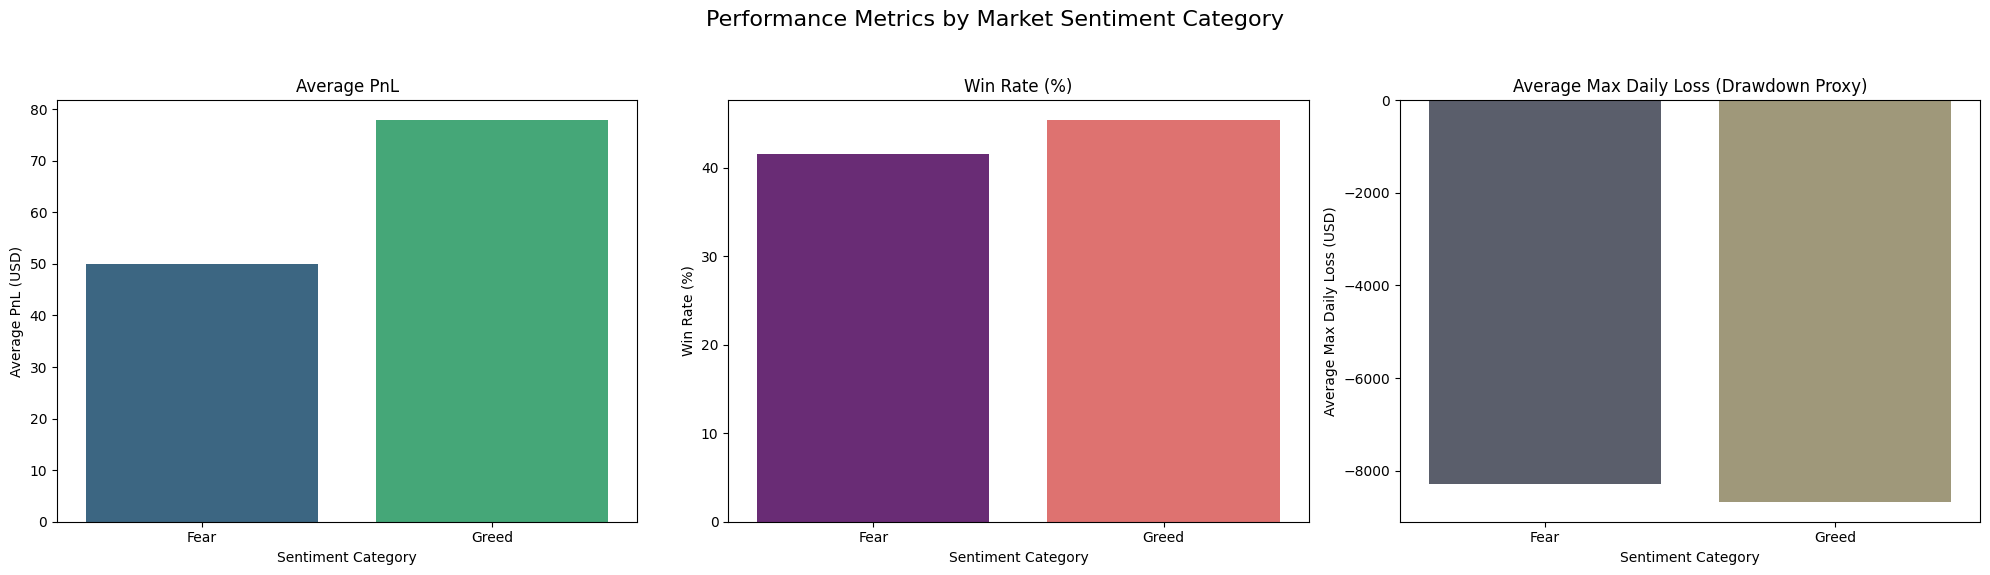

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Performance Metrics by Market Sentiment Category', fontsize=16)

# Plot Average PnL
sns.barplot(x='sentiment_category', y='Average Closed PnL', data=avg_pnl_by_sentiment, ax=axes[0], palette='viridis')
axes[0].set_title('Average PnL')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Average PnL (USD)')

# Plot Win Rate
sns.barplot(x='sentiment_category', y='win_rate', data=win_rate_by_sentiment, ax=axes[1], palette='magma')
axes[1].set_title('Win Rate (%)')
axes[1].set_xlabel('Sentiment Category')
axes[1].set_ylabel('Win Rate (%)')

# Plot Drawdown Proxy
sns.barplot(x='sentiment_category', y='Average Max Daily Loss (Proxy)', data=drawdown_proxy_by_sentiment, ax=axes[2], palette='cividis')
axes[2].set_title('Average Max Daily Loss (Drawdown Proxy)')
axes[2].set_xlabel('Sentiment Category')
axes[2].set_ylabel('Average Max Daily Loss (USD)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Part C: Trader Behavior Analysis based on Market Sentiment

To understand if traders change their behavior based on sentiment, we will analyze several metrics by `sentiment_category` ('Fear' vs. 'Greed'):
1.  **Trade Frequency:** Average number of trades per account.
2.  **Long/Short Bias:** Average Long/Short Ratio.
3.  **Position Sizes:** Average trade size (in USD).
4.  **Leverage:** Reiterate data unavailability.

#### 1. Trade Frequency by Sentiment Category

In [ ]:
# Calculate total trades per account per sentiment category
trades_per_account_sentiment = sentiment_performance_df.groupby(['Account', 'sentiment_category'])['Trade ID'].count().reset_index()

# Calculate average trades per account per sentiment category
avg_trade_frequency_by_sentiment = trades_per_account_sentiment.groupby('sentiment_category')['Trade ID'].mean().reset_index()
avg_trade_frequency_by_sentiment.rename(columns={'Trade ID': 'Average Trades Per Account'}, inplace=True)

print("\n--- Average Trade Frequency by Sentiment Category ---")
display(avg_trade_frequency_by_sentiment)


--- Average Trade Frequency by Sentiment Category ---


,sentiment_category,Average Trades Per Account
0,Fear,4183.468750
1,Greed,1491.413793


#### 2. Long/Short Bias by Sentiment Category

In [ ]:
# Calculate total BUY and SELL trades per sentiment category
long_short_bias_sentiment = sentiment_performance_df.groupby('sentiment_category')['Side'].value_counts().unstack(fill_value=0).reset_index()

# Calculate long/short ratio for each sentiment category
long_short_bias_sentiment['long_short_ratio'] = long_short_bias_sentiment.apply(
    lambda row: row['BUY'] / row['SELL'] if row['SELL'] != 0 else (row['BUY'] / 1e-6 if row['BUY'] !=0 else 0),
    axis=1
)

print("\n--- Long/Short Bias (Ratio) by Sentiment Category ---")
display(long_short_bias_sentiment)


--- Long/Short Bias (Ratio) by Sentiment Category ---


Side,sentiment_category,BUY,SELL,long_short_ratio
0,Fear,66081,67790,0.974790
1,Greed,18792,24459,0.768306


#### 3. Average Position Sizes by Sentiment Category

In [ ]:
# Calculate average trade size (Size USD) per sentiment category
avg_position_size_by_sentiment = sentiment_performance_df.groupby('sentiment_category')['Size USD'].mean().reset_index()
avg_position_size_by_sentiment.rename(columns={'Size USD': 'Average Position Size (USD)'}, inplace=True)

print("\n--- Average Position Size by Sentiment Category ---")
display(avg_position_size_by_sentiment)


--- Average Position Size by Sentiment Category ---


,sentiment_category,Average Position Size (USD)
0,Fear,5259.977837
1,Greed,3581.661513


### Visualizing Trader Behavior by Sentiment

/tmp/ipykernel_3463/2307581602.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_category', y='Average Trades Per Account', data=avg_trade_frequency_by_sentiment, ax=axes[0], palette='viridis')
/tmp/ipykernel_3463/2307581602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_category', y='long_short_ratio', data=long_short_bias_sentiment, ax=axes[1], palette='magma')
/tmp/ipykernel_3463/2307581602.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_category', y='Average Position Size (USD)', data=a

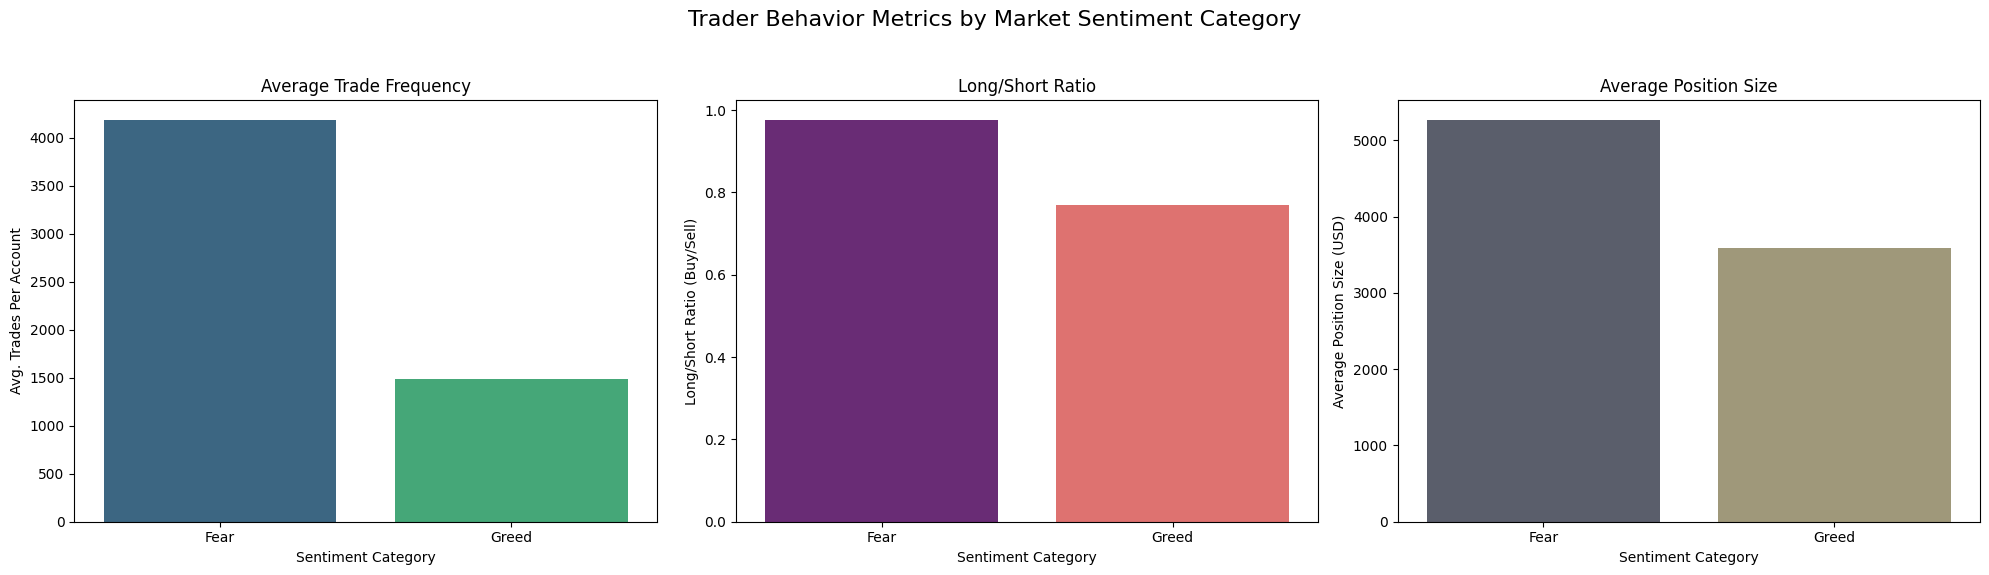

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Trader Behavior Metrics by Market Sentiment Category', fontsize=16)

# Plot Average Trade Frequency
sns.barplot(x='sentiment_category', y='Average Trades Per Account', data=avg_trade_frequency_by_sentiment, ax=axes[0], palette='viridis')
axes[0].set_title('Average Trade Frequency')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Avg. Trades Per Account')

# Plot Long/Short Ratio
sns.barplot(x='sentiment_category', y='long_short_ratio', data=long_short_bias_sentiment, ax=axes[1], palette='magma')
axes[1].set_title('Long/Short Ratio')
axes[1].set_xlabel('Sentiment Category')
axes[1].set_ylabel('Long/Short Ratio (Buy/Sell)')

# Plot Average Position Size
sns.barplot(x='sentiment_category', y='Average Position Size (USD)', data=avg_position_size_by_sentiment, ax=axes[2], palette='cividis')
axes[2].set_title('Average Position Size')
axes[2].set_xlabel('Sentiment Category')
axes[2].set_ylabel('Average Position Size (USD)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Part D: Trader Segmentation Analysis

We will identify trader segments based on two criteria:
1.  **Frequent vs Infrequent Traders:** Based on the total number of trades per account.
2.  **Consistent Winners vs Inconsistent Traders:** Based on win rate.

For each segment, we will provide insights backed by tables and visualizations.

#### Segment 1: Frequent vs Infrequent Traders

To categorize traders, we'll use the total number of trades per account. We'll define 'Infrequent Traders' as those in the bottom 25th percentile of total trades and 'Frequent Traders' as those in the top 75th percentile.

In [ ]:
# Merge account_performance with average trade size for a comprehensive view
account_metrics = pd.merge(account_performance, avg_trade_size_per_account, on='Account', how='left')

# Define thresholds for frequent vs infrequent traders based on total_trades
infrequent_threshold = account_metrics['total_trades'].quantile(0.25)
frequent_threshold = account_metrics['total_trades'].quantile(0.75)

def categorize_frequency(num_trades):
    if num_trades <= infrequent_threshold:
        return 'Infrequent'
    elif num_trades >= frequent_threshold:
        return 'Frequent'
    else:
        return 'Medium'

account_metrics['frequency_segment'] = account_metrics['total_trades'].apply(categorize_frequency)

# Filter for only Frequent and Infrequent for this analysis
frequency_segments_df = account_metrics[account_metrics['frequency_segment'].isin(['Frequent', 'Infrequent'])].copy()

print("--- Trader Frequency Segment Distribution ---")
display(frequency_segments_df['frequency_segment'].value_counts())


--- Trader Frequency Segment Distribution ---


,count
frequency_segment,
Frequent,8
Infrequent,8


##### Insight 1.1: Average PnL by Trader Frequency Segment


--- Average Total PnL by Trader Frequency Segment ---


,frequency_segment,Total PnL
0,Frequent,677728.702212
1,Infrequent,113690.283082


/tmp/ipykernel_3463/2371440225.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency_segment', y='Total PnL', data=avg_pnl_by_frequency, palette='viridis')


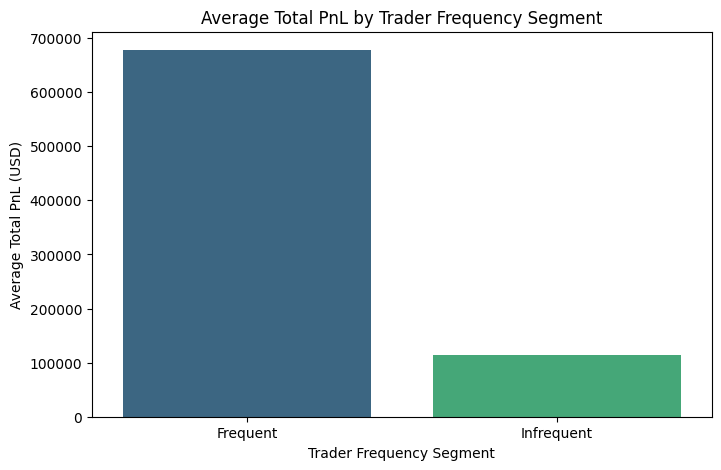

In [ ]:
# Calculate average PnL for each frequency segment
# We need to merge with daily_pnl_per_account or calculate total PnL from merged_df for each account first

# Calculate total PnL per account from the original merged_df for accuracy
total_pnl_per_account = merged_df.groupby('Account')['Closed PnL'].sum().reset_index()
total_pnl_per_account.rename(columns={'Closed PnL': 'Total PnL'}, inplace=True)

# Merge total_pnl_per_account with frequency_segments_df
frequency_pnl_df = pd.merge(frequency_segments_df, total_pnl_per_account, on='Account', how='left')

avg_pnl_by_frequency = frequency_pnl_df.groupby('frequency_segment')['Total PnL'].mean().reset_index()

print("\n--- Average Total PnL by Trader Frequency Segment ---")
display(avg_pnl_by_frequency)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='frequency_segment', y='Total PnL', data=avg_pnl_by_frequency, palette='viridis')
plt.title('Average Total PnL by Trader Frequency Segment')
plt.xlabel('Trader Frequency Segment')
plt.ylabel('Average Total PnL (USD)')
plt.show()


##### Insight 1.2: Win Rate by Trader Frequency Segment


--- Average Win Rate by Trader Frequency Segment ---


,frequency_segment,win_rate
0,Frequent,43.641946
1,Infrequent,42.323760


/tmp/ipykernel_3463/2655997828.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency_segment', y='win_rate', data=avg_win_rate_by_frequency, palette='magma')


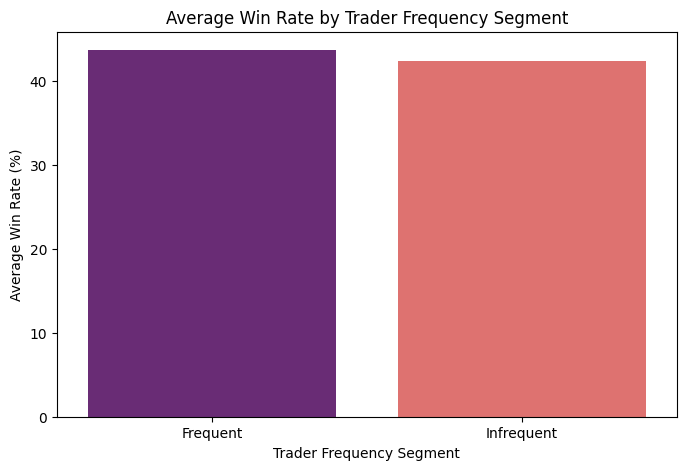

In [ ]:
# Average win rate per frequency segment (already available in account_metrics)
avg_win_rate_by_frequency = frequency_segments_df.groupby('frequency_segment')['win_rate'].mean().reset_index()

print("\n--- Average Win Rate by Trader Frequency Segment ---")
display(avg_win_rate_by_frequency)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='frequency_segment', y='win_rate', data=avg_win_rate_by_frequency, palette='magma')
plt.title('Average Win Rate by Trader Frequency Segment')
plt.xlabel('Trader Frequency Segment')
plt.ylabel('Average Win Rate (%)')
plt.show()


##### Insight 1.3: Average Trade Size by Trader Frequency Segment


--- Average Trade Size by Trader Frequency Segment ---


,frequency_segment,Average Trade Size (USD)
0,Frequent,6061.397359
1,Infrequent,3360.706782


/tmp/ipykernel_3463/313208720.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency_segment', y='Average Trade Size (USD)', data=avg_trade_size_by_frequency, palette='cividis')


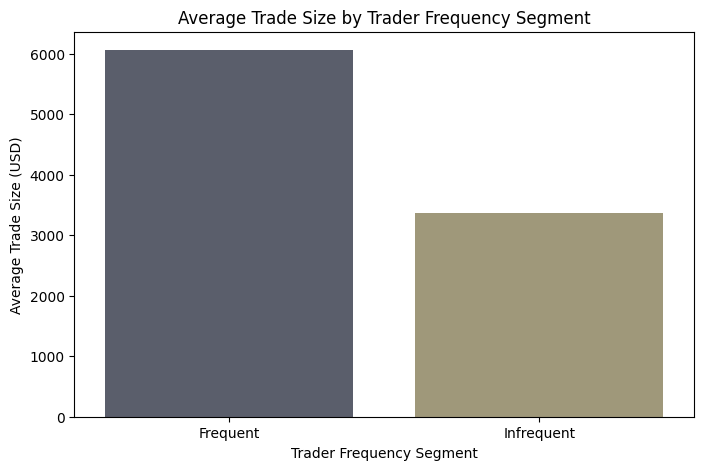

In [ ]:
# Average trade size per frequency segment (already available in account_metrics)
avg_trade_size_by_frequency = frequency_segments_df.groupby('frequency_segment')['Average Trade Size (USD)'].mean().reset_index()

print("\n--- Average Trade Size by Trader Frequency Segment ---")
display(avg_trade_size_by_frequency)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='frequency_segment', y='Average Trade Size (USD)', data=avg_trade_size_by_frequency, palette='cividis')
plt.title('Average Trade Size by Trader Frequency Segment')
plt.xlabel('Trader Frequency Segment')
plt.ylabel('Average Trade Size (USD)')
plt.show()


#### Segment 2: Consistent Winners vs Inconsistent Traders

For this segment, we'll use `win_rate` to define consistent and inconsistent traders. 'Consistent Winners' will be those in the top 75th percentile of win rates, and 'Inconsistent Traders' will be those in the bottom 25th percentile.

In [ ]:
# Define thresholds for consistent vs inconsistent traders based on win_rate
inconsistent_threshold = account_metrics['win_rate'].quantile(0.25)
consistent_threshold = account_metrics['win_rate'].quantile(0.75)

def categorize_win_rate(win_rate):
    if win_rate <= inconsistent_threshold:
        return 'Inconsistent'
    elif win_rate >= consistent_threshold:
        return 'Consistent Winner'
    else:
        return 'Medium'

account_metrics['win_rate_segment'] = account_metrics['win_rate'].apply(categorize_win_rate)

# Filter for only Consistent Winners and Inconsistent Traders for this analysis
win_rate_segments_df = account_metrics[account_metrics['win_rate_segment'].isin(['Consistent Winner', 'Inconsistent'])].copy()

print("--- Trader Win Rate Segment Distribution ---")
display(win_rate_segments_df['win_rate_segment'].value_counts())


--- Trader Win Rate Segment Distribution ---


,count
win_rate_segment,
Inconsistent,8
Consistent Winner,8


##### Insight 2.1: Average Total PnL by Win Rate Segment


--- Average Total PnL by Trader Win Rate Segment ---


,win_rate_segment,Total PnL
0,Consistent Winner,334668.159055
1,Inconsistent,119913.958703


/tmp/ipykernel_3463/534309738.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate_segment', y='Total PnL', data=avg_pnl_by_win_rate_segment, palette='viridis')


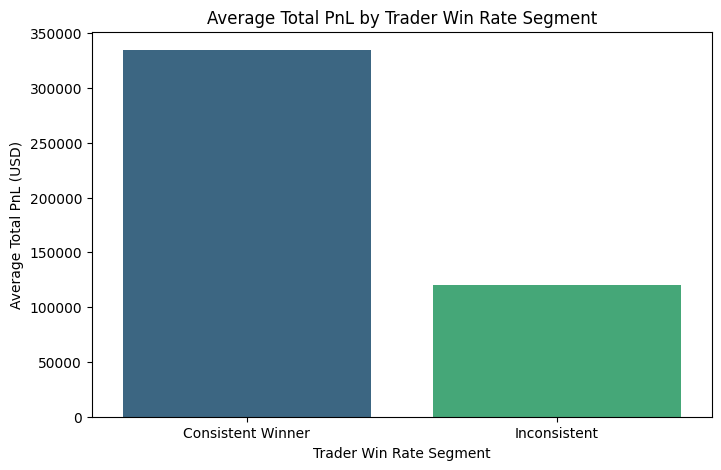

In [ ]:
# Merge total_pnl_per_account with win_rate_segments_df
win_rate_pnl_df = pd.merge(win_rate_segments_df, total_pnl_per_account, on='Account', how='left')

avg_pnl_by_win_rate_segment = win_rate_pnl_df.groupby('win_rate_segment')['Total PnL'].mean().reset_index()

print("\n--- Average Total PnL by Trader Win Rate Segment ---")
display(avg_pnl_by_win_rate_segment)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='win_rate_segment', y='Total PnL', data=avg_pnl_by_win_rate_segment, palette='viridis')
plt.title('Average Total PnL by Trader Win Rate Segment')
plt.xlabel('Trader Win Rate Segment')
plt.ylabel('Average Total PnL (USD)')
plt.show()


##### Insight 2.2: Average Trade Size by Win Rate Segment


--- Average Trade Size by Trader Win Rate Segment ---


,win_rate_segment,Average Trade Size (USD)
0,Consistent Winner,3459.346386
1,Inconsistent,5201.377550


/tmp/ipykernel_3463/1821167539.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate_segment', y='Average Trade Size (USD)', data=avg_trade_size_by_win_rate_segment, palette='magma')


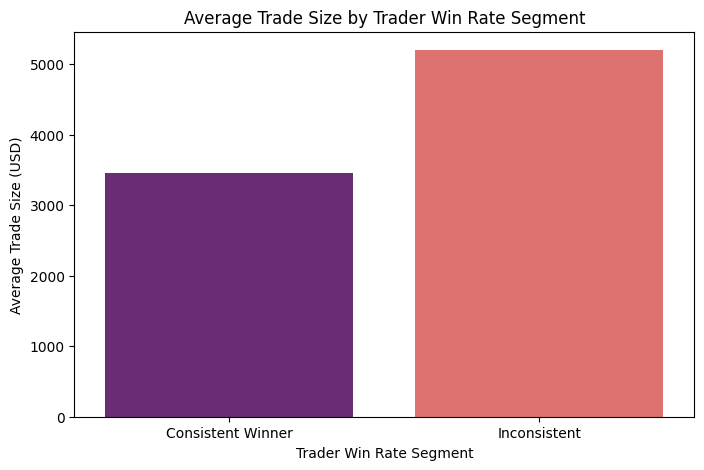

In [ ]:
# Average trade size per win rate segment
avg_trade_size_by_win_rate_segment = win_rate_segments_df.groupby('win_rate_segment')['Average Trade Size (USD)'].mean().reset_index()

print("\n--- Average Trade Size by Trader Win Rate Segment ---")
display(avg_trade_size_by_win_rate_segment)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='win_rate_segment', y='Average Trade Size (USD)', data=avg_trade_size_by_win_rate_segment, palette='magma')
plt.title('Average Trade Size by Trader Win Rate Segment')
plt.xlabel('Trader Win Rate Segment')
plt.ylabel('Average Trade Size (USD)')
plt.show()


##### Insight 2.3: Average Trade Frequency by Win Rate Segment


--- Average Trade Frequency by Trader Win Rate Segment ---


,win_rate_segment,Average Total Trades
0,Consistent Winner,5185.125
1,Inconsistent,3804.500


/tmp/ipykernel_3463/2674995768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate_segment', y='Average Total Trades', data=avg_freq_by_win_rate_segment, palette='cividis')


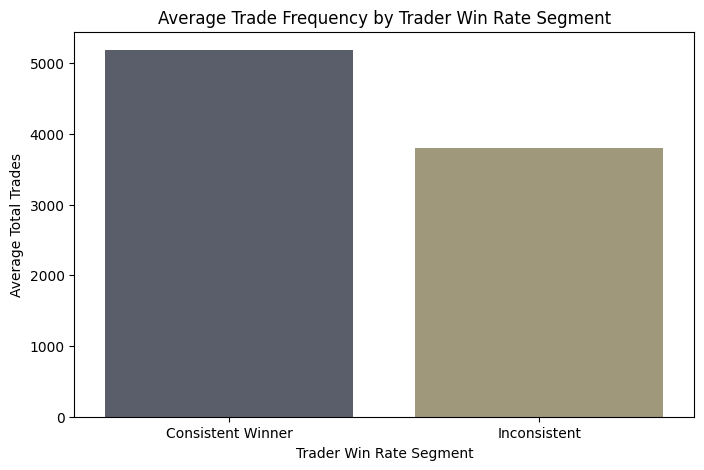

In [ ]:
# Average trade frequency per win rate segment
avg_freq_by_win_rate_segment = win_rate_segments_df.groupby('win_rate_segment')['total_trades'].mean().reset_index()
avg_freq_by_win_rate_segment.rename(columns={'total_trades': 'Average Total Trades'}, inplace=True)

print("\n--- Average Trade Frequency by Trader Win Rate Segment ---")
display(avg_freq_by_win_rate_segment)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='win_rate_segment', y='Average Total Trades', data=avg_freq_by_win_rate_segment, palette='cividis')
plt.title('Average Trade Frequency by Trader Win Rate Segment')
plt.xlabel('Trader Win Rate Segment')
plt.ylabel('Average Total Trades')
plt.show()
